In [ ]:
## What we'll do:

# Step 1: Setup MLflow experiment
# Step 2: Train Random Forest → log to MLflow
# Step 3: Train XGBoost → log to MLflow
# Step 4: Compare runs in MLflow UI
# Step 5: Pick best model

In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports successful!")

✅ Imports successful!


In [2]:
# Load Processed Data
X_train = pd.read_csv('../data/processed/X_train.csv')
X_val = pd.read_csv('../data/processed/X_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_val = pd.read_csv('../data/processed/y_val.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print("✅ Data loaded!")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

✅ Data loaded!
X_train: (70000, 22)
X_val:   (15000, 22)
X_test:  (15000, 22)


In [3]:
# Setup MLflow Experiment
# Set MLflow experiment
mlflow.set_experiment("credit-score-classification")

print("✅ MLflow experiment set!")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

2026/03/01 12:15:06 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/01 12:15:06 INFO mlflow.store.db.utils: Updating database tables
2026/03/01 12:15:08 INFO mlflow.tracking.fluent: Experiment with name 'credit-score-classification' does not exist. Creating a new experiment.


✅ MLflow experiment set!
Tracking URI: sqlite:///D:/ml-mlops/ml-classification/notebooks/mlflow.db


In [ ]:
# MLflow experiment named credit-score-classification is created ✅
# Tracking URI — MLflow is storing all experiment logs in a local SQLite database at mlflow.
# What is mlflow.db?
# It's a SQLite database — a single file that stores all your experiment data locally.
# What gets stored in it:
# mlflow.db
# ├── Experiments (credit-score-classification)
# │   ├── Run 1: RandomForest
# │   │   ├── params: n_estimators=100, max_depth=10
# │   │   ├── metrics: accuracy=0.85, f1=0.83
# │   │   └── artifacts: model files
# │   ├── Run 2: XGBoost
# │   │   ├── params: n_estimators=200
# │   │   ├── metrics: accuracy=0.89, f1=0.88
# │   │   └── artifacts: model files

# notebooks/
# ├── mlflow.db          ← experiment metadata
# └── mlruns/            ← actual artifacts (models, plots)
#     └── 1/
#         ├── run1/
#         │   └── artifacts/
#         └── run2/
#             └── artifacts/

# Run:
# cd notebooks
# mlflow ui
# Opens at http://localhost:5000 — visual dashboard to compare all runs

In [6]:
# Train Random Forest + Log to MLflow
with mlflow.start_run(run_name="RandomForest_baseline"):
    
    # Params
    params = {
        "n_estimators": 100,
        "max_depth": 10,
        "random_state": 42,
        "class_weight": "balanced"  # handles class imbalance
    }
    
    # Train
    rf_model = RandomForestClassifier(**params)
    rf_model.fit(X_train, y_train)
    
    # Evaluate on validation set
    y_pred = rf_model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    
    # Log to MLflow
    mlflow.log_params(params)
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("val_f1_score", f1)
    mlflow.sklearn.log_model(rf_model, "random_forest_model")
    
    print(f"✅ Random Forest trained!")
    print(f"Validation Accuracy: {acc:.4f}")
    print(f"Validation F1 Score: {f1:.4f}")
    print(f"\n{classification_report(y_val, y_pred)}")

2026/03/01 12:25:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 12:25:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Random Forest trained!
Validation Accuracy: 0.6797
Validation F1 Score: 0.6825

              precision    recall  f1-score   support

           0       0.50      0.81      0.62      2674
           1       0.84      0.58      0.69      7976
           2       0.65      0.78      0.71      4350

    accuracy                           0.68     15000
   macro avg       0.67      0.72      0.67     15000
weighted avg       0.73      0.68      0.68     15000



In [ ]:
# Observations
# Accuracy: 68% — baseline, can improve
# Class 0 (Good):     precision 0.50 — struggling ⚠️
# Class 1 (Standard): precision 0.84 — good ✅
# Class 2 (Poor):     precision 0.65 — decent

In [7]:
# Train XGBoost + Log to 
with mlflow.start_run(run_name="XGBoost_baseline"):
    
    # Params
    params = {
        "n_estimators": 200,
        "max_depth": 6,
        "learning_rate": 0.1,
        "random_state": 42,
        "eval_metric": "mlogloss",
        "use_label_encoder": False
    }
    
    # Train
    xgb_model = xgb.XGBClassifier(**params)
    xgb_model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = xgb_model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    
    # Log to MLflow
    mlflow.log_params(params)
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("val_f1_score", f1)
    mlflow.xgboost.log_model(xgb_model, "xgboost_model")
    
    print(f"✅ XGBoost trained!")
    print(f"Validation Accuracy: {acc:.4f}")
    print(f"Validation F1 Score: {f1:.4f}")
    print(f"\n{classification_report(y_val, y_pred)}")


2026/03/01 12:27:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ XGBoost trained!
Validation Accuracy: 0.7424
Validation F1 Score: 0.7423

              precision    recall  f1-score   support

           0       0.64      0.67      0.66      2674
           1       0.77      0.79      0.78      7976
           2       0.77      0.70      0.73      4350

    accuracy                           0.74     15000
   macro avg       0.72      0.72      0.72     15000
weighted avg       0.74      0.74      0.74     15000



In [8]:
# Tune XGBoost + Log to MLflow
with mlflow.start_run(run_name="XGBoost_tuned"):
    
    params = {
        "n_estimators": 500,
        "max_depth": 8,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42,
        "eval_metric": "mlogloss",
    }
    
    xgb_tuned = xgb.XGBClassifier(**params)
    xgb_tuned.fit(X_train, y_train)
    
    y_pred = xgb_tuned.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    
    mlflow.log_params(params)
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("val_f1_score", f1)
    mlflow.xgboost.log_model(xgb_tuned, "xgboost_tuned_model")
    
    print(f"✅ XGBoost Tuned trained!")
    print(f"Validation Accuracy: {acc:.4f}")
    print(f"Validation F1 Score: {f1:.4f}")
    print(f"\n{classification_report(y_val, y_pred)}")

2026/03/01 12:30:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ XGBoost Tuned trained!
Validation Accuracy: 0.7775
Validation F1 Score: 0.7772

              precision    recall  f1-score   support

           0       0.72      0.71      0.71      2674
           1       0.79      0.81      0.80      7976
           2       0.79      0.76      0.77      4350

    accuracy                           0.78     15000
   macro avg       0.77      0.76      0.76     15000
weighted avg       0.78      0.78      0.78     15000



In [9]:
# Evaluate Best Model on Test Set
# Final evaluation on test set
y_pred_test = xgb_tuned.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test, average='weighted')

print(f"✅ Final Test Evaluation!")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print(f"\n{classification_report(y_test, y_pred_test)}")

# Log test metrics to MLflow
with mlflow.start_run(run_name="XGBoost_tuned_test_eval"):
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.log_metric("test_f1_score", test_f1)
    mlflow.xgboost.log_model(xgb_tuned, "best_model")
    print(f"\n✅ Test metrics logged to MLflow!")

2026/03/01 12:32:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Final Test Evaluation!
Test Accuracy: 0.7721
Test F1 Score: 0.7717

              precision    recall  f1-score   support

           0       0.72      0.69      0.71      2675
           1       0.79      0.81      0.80      7976
           2       0.78      0.76      0.77      4349

    accuracy                           0.77     15000
   macro avg       0.76      0.75      0.76     15000
weighted avg       0.77      0.77      0.77     15000


✅ Test metrics logged to MLflow!


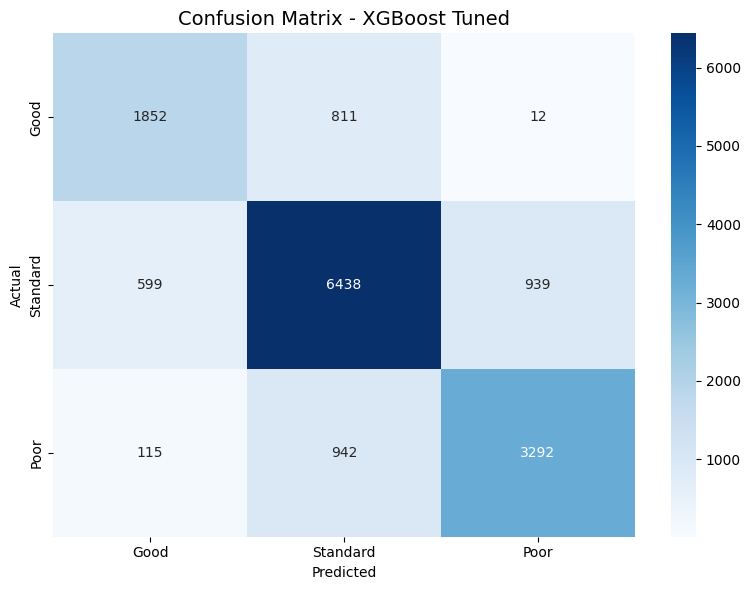

In [10]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good', 'Standard', 'Poor'],
            yticklabels=['Good', 'Standard', 'Poor'])
plt.title('Confusion Matrix - XGBoost Tuned', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
# Key Insights:

# Standard↔Poor confusion is the biggest issue — makes sense, they're similar
# Good→Standard confusion — minority class struggling
# Good→Poor = only 12 — model rarely makes extreme mistakes

In [11]:
# Now Save + Commit Everything
# Save Model
import pickle
import os

os.makedirs('../models', exist_ok=True)

with open('../models/xgboost_tuned.pkl', 'wb') as f:
    pickle.dump(xgb_tuned, f)

print("✅ Model saved to models/xgboost_tuned.pkl")

✅ Model saved to models/xgboost_tuned.pkl


In [12]:
# Register Model in MLflow Registry
# Get the best run ID
best_run = mlflow.search_runs(
    experiment_names=["credit-score-classification"],
    order_by=["metrics.val_accuracy DESC"]
).iloc[0]

best_run_id = best_run.run_id
print(f"Best Run ID: {best_run_id}")
print(f"Best Val Accuracy: {best_run['metrics.val_accuracy']:.4f}")

# Register model
model_uri = f"runs:/{best_run_id}/xgboost_tuned_model"
registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="credit-score-classifier"
)

print(f"\n✅ Model registered!")
print(f"Model Name: {registered_model.name}")
print(f"Model Version: {registered_model.version}")

Successfully registered model 'credit-score-classifier'.
2026/03/01 12:42:58 WARNING mlflow.tracking._model_registry.fluent: Run with id c135701aaf37413b9a2f6d00bd3c9136 has no artifacts at artifact path 'xgboost_tuned_model', registering model based on models:/m-8fc6749ea8dc4c2085ba27401dbcc0fb instead


Best Run ID: c135701aaf37413b9a2f6d00bd3c9136
Best Val Accuracy: 0.7775

✅ Model registered!
Model Name: credit-score-classifier
Model Version: 1


Created version '1' of model 'credit-score-classifier'.


In [ ]:
# MLflow Model Stages — Explained
# None → Staging → Production → Archived

# Stage 1: None
# Just trained XGBoost Tuned → 77% accuracy
# Registered in MLflow
# No decision made yet

# Stage 2: Staging
# Send to QA/Testing team
# Run more tests:
#   - Test on unseen data
#   - Check bias/fairness
#   - Performance benchmarks
# "Is this model good enough?"

# Stage 3: 

# Passed all tests ✅
# Now serving real users
# API uses THIS model to predict
# Credit Score → Good/Standard/Poor

# Stage 4: Archived

# New better model (v2) trained → 85% accuracy
# Old model (v1) → Archived
# No longer used but kept for reference




In [13]:
# Model promoted to Production!
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Transition model to Production
client.transition_model_version_stage(
    name="credit-score-classifier",
    version=1,
    stage="Production"
)

print("✅ Model promoted to Production!")

# Verify
model_details = client.get_model_version(
    name="credit-score-classifier",
    version=1
)
print(f"Model Stage: {model_details.current_stage}")
print(f"Model Version: {model_details.version}")

✅ Model promoted to Production!
Model Stage: Production
Model Version: 1
